# Zbiory rozmyte (iris dataset)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Analiza rozmyta dla kwiatka: [4.9 3.  1.4 0.2]
--------------------------------------------------
Cecha: sepal length (cm) (wartość: 4.9)
  -> Przynależność do setosa    : 0.9549
  -> Przynależność do versicolor: 0.1281
  -> Przynależność do virginica : 0.0275

Cecha: sepal width (cm) (wartość: 3.0)
  -> Przynależność do setosa    : 0.5218
  -> Przynależność do versicolor: 0.7603
  -> Przynależność do virginica : 0.9967

Cecha: petal length (cm) (wartość: 1.4)
  -> Przynależność do setosa    : 0.9370
  -> Przynależność do versicolor: 0.0000
  -> Przynależność do virginica : 0.0000

Cecha: petal width (cm) (wartość: 0.2)
  -> Przynależność do setosa    : 0.9074
  -> Przynależność do versicolor: 0.0000
  -> Przynależność do virginica : 0.0000



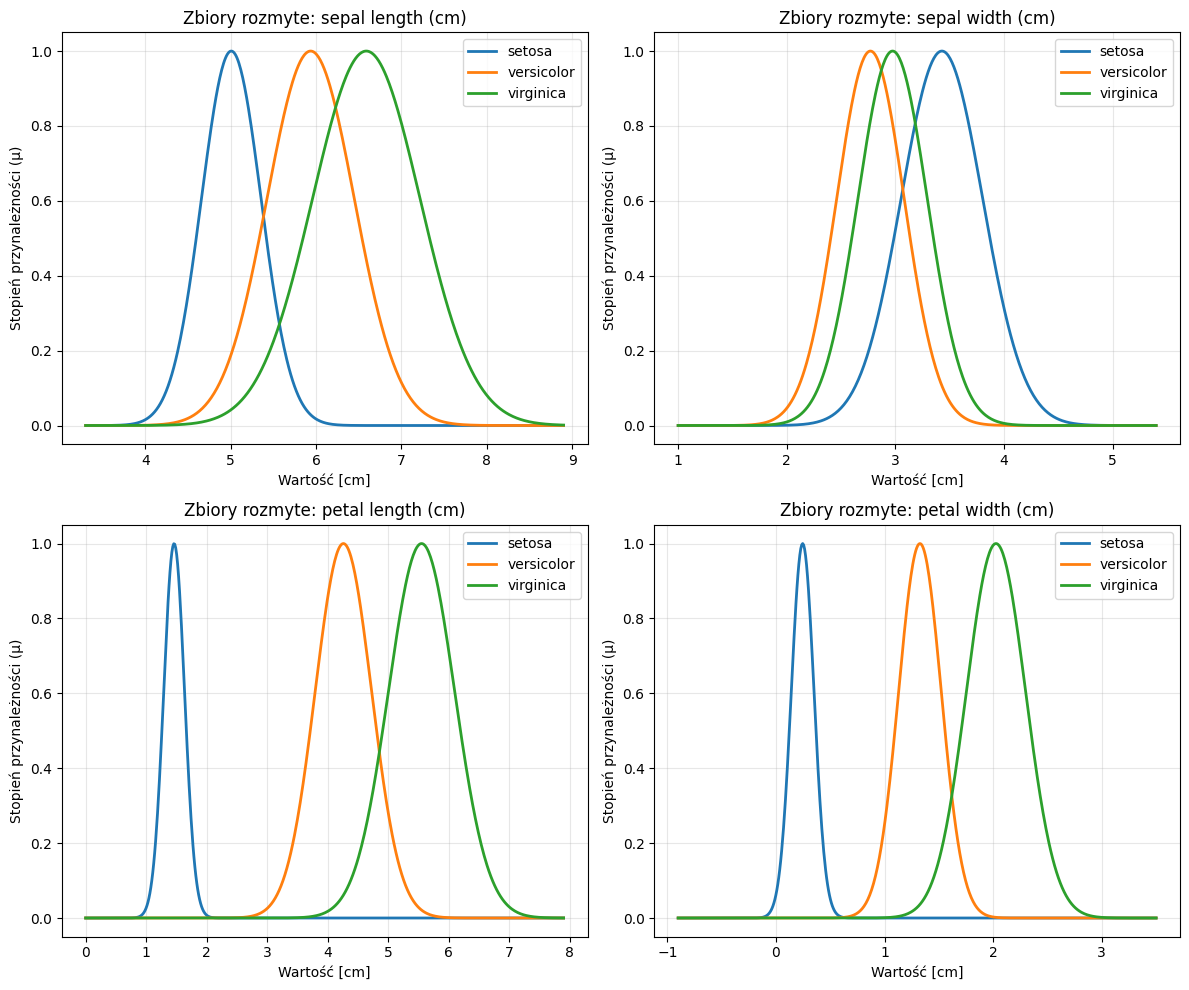

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names



# print(X)
# print(y)
print(feature_names)

# 12 zbiorów rozmytych

# definicja funkcji gaussa
def gauss(x, m, sigma):
  return np.exp(-((x - m) ** 2) / (2 * sigma ** 2))


# parametry m i sigma, zagnieżdżone słowniki
model_params = {}
for i, f_name in enumerate(feature_names):
    model_params[f_name] = {}
    for t_idx, t_name in enumerate(iris.target_names):
        data = X[y == t_idx, i]
        model_params[f_name][t_name] = {
            'm': np.mean(data),
            's': np.std(data)
        }
#print(model_params)
sample = X[1]
print(f"Analiza rozmyta dla kwiatka: {sample}")
print("-" * 50)

for i, f_name in enumerate(feature_names):
    val = sample[i] # Wartość konkretnej cechy, np. 5.1
    print(f"Cecha: {f_name} (wartość: {val})")

    for t_name in iris.target_names:
        # Pobieramy parametry wyliczone wcześniej
        m = model_params[f_name][t_name]['m']
        s = model_params[f_name][t_name]['s']

        # TUTAJ używamy Twojej funkcji!
        stopien_przynaleznosci = gauss(val, m, s)

        print(f"  -> Przynależność do {t_name:10}: {stopien_przynaleznosci:.4f}")
    print()

# Tworzymy siatkę wykresów 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # spłaszczamy macierz wykresów do listy, żeby łatwiej pętlować

for i, f_name in enumerate(feature_names):
    ax = axes[i]

    # Określamy zakres osi X (od minimum do maksimum danej cechy w całym zbiorze)
    x_min, x_max = X[:, i].min() - 1, X[:, i].max() + 1
    x_range = np.linspace(x_min, x_max, 500)

    for t_idx, t_name in enumerate(iris.target_names):
        m = model_params[f_name][t_name]['m']
        s = model_params[f_name][t_name]['s']

        # UŻYCIE TWOJEJ FUNKCJI GAUSSA
        y_vals = gauss(x_range, m, s)

        ax.plot(x_range, y_vals, label=t_name, linewidth=2)

    ax.set_title(f"Zbiory rozmyte: {f_name}")
    ax.set_xlabel("Wartość [cm]")
    ax.set_ylabel("Stopień przynależności (μ)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Wyświetlanie w czytelnej formie
# for feature, classes in model_params.items():
#     print(f"\n>>> Cecha: {feature.upper()}")
#     for class_name, p in classes.items():
#         print(f"  {class_name:10} | m: {p['m']:.2f} | sigma: {p['s']:.2f}")

